<a href="https://colab.research.google.com/github/sgruyzcki/DiploDatos2026/blob/main/Entregable_Parte_1_Grupo_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

##**Edición 2026**

---
## Trabajo práctico entregable - Parte 1

## Grupo 3:


*   BAGGINI, Mariano
*   DA SILVA, Rocio
*   GRUZYCKI, Sergio
*   NEDEL, Agustina  



In [ ]:
import io
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_context('talk')

## Ejercicio 1 - Análisis descriptivo

Responder a la pregunta: **¿Cuáles son los lenguajes de programación asociados a los mejores salarios?**

Para ello:
1. Seleccionar las columnas relevantes para analizar.
2. Seleccionar las filas relevantes para analizar. Esto incluye la eliminación de valores extremos y erróneos, pero también puede enfocar el análisis en una sub-población. Por ejemplo, se pueden limitar a personas con un salario mayor que 300000 pesos, o a las personas que trabajan sólo en "Data Science", pero deben justificar su elección y reformular la pregunta inicial de ser necesario.
  * Obtener una lista de los lenguajes de programación más populares. Decidir cuántos y cuáles seleccionan para incluir en el análisis.
  * Para cada una de las otras columnas del punto anterior, elegir los rangos o valores seleccionan para incluir en el análisis.
3. Seleccionar métricas que ayuden a responder la pregunta, y los métodos para analizarlas. Elegir UNA de las siguientes opciones:
  * Comparar las distribuciones de salario para cada lenguaje utilizando visualizaciones. Como la visualización es el producto final, debe ser clara y mostrar información relevante.
  * Comparar medidas de estadística descriptiva sobre la distribución de salario para cada lenguaje. Sean creativos, la estadística descriptiva nos permite decir cosas como: "el 10% de los mejores sueldos los ganan, en su mayoría, programadores que saben kotlin!" (donde *mayoría* es un término medio engañoso que sólo significa más del 50%). Para comparar múltiples lenguajes, les recomendamos usar también visualizaciones.
  * Comparar probabilidades. Por ejemplo: "Si sabés Python o Java, tenés un 30% más de chances de ganar arriba de 1000K".

Si lo consideran necesario, realicen varias iteraciones. Es decir, si encuentran que las distribuciones de los lenguajes de programación que seleccionaron inicialmente no son muy diferentes, pueden re-hacer el análisis usando sólo los lenguajes de programación que son diferentes.

### Resolución del ejercicio 1

1. Selección de las columnas relevantes a analizar.

  *   **tools_programming_languages**: Porque es la variable predictora. Es la columna que contiene la información central de la pregunta.

  *   **salary_monthly_neto**: Es la variable de respuesta. Se prefiere el salario neto sobre el bruto porque refleja la realidad del bolsillo. Mientras que el bruto incluye cargas sociales e impuestos que varían.

  *   **work_seniority**: Considera la experiencia, permite validar si un lenguaje es bien pagado incluso para alguien que recien empieza. En este caso, se emplea como validación datos porque puedo saber si realmente es un lenguaje bien remunerado en todos los niveles.

  *   **work_dedication**: Considera la duración de la jornada laboral usual. Se utiliza para segmentar la población.



### Lectura del dataset

In [ ]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/master/sysarmy_survey_2026_processed.csv'
df = pd.read_csv(url)
df_raw = df.copy()
df_raw.head(3)

,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,salary_inflation_adjustment,...,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,salir_o_seguir_contestando_sobre_estudios,profile_age,profile_gender,profile_previous_survey,company_best_companies,sueldo_dolarizado,work_seniority,_sal
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,NaN,NaN,NaN,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0
1,Santa Fe,Full-Time,Contractor,5000000.0,5000000.0,Cobro todo el salario en dólares,1400,No,No recibo bono,No,...,NaN,NaN,NaN,50,Mujer Cis,Sí,NaN,True,Senior,5000000.0
2,Buenos Aires,Full-Time,Tercerizado (trabajo a través de consultora o ...,4600000.0,3600000.0,Cobro parte del salario en dólares,1436,No,No recibo bono,Uno,...,0.0,Porcentaje de mi sueldo bruto,Terminar encuesta,36,Mujer Cis,Sí,NaN,True,Senior,4600000.0


In [ ]:
# Columnas a utilizar en el analisis
relevant_columns = ['tools_programming_languages', 'salary_monthly_NETO',
                    'work_dedication', 'work_seniority']

1.5 Exploración inicial de los datos

In [ ]:
# Observación general de los datos
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4939 entries, 0 to 4938
Data columns (total 60 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   work_province                                         4939 non-null   object 
 1   work_dedication                                       4939 non-null   object 
 2   work_contract_type                                    4939 non-null   object 
 3   salary_monthly_BRUTO                                  4939 non-null   float64
 4   salary_monthly_NETO                                   4717 non-null   float64
 5   salary_in_usd                                         1583 non-null   object 
 6   salary_last_dollar_value                              1028 non-null   object 
 7   salary_has_bonus                                      4939 non-null   object 
 8   salary_bonus_tied_to                                  4938

In [ ]:
# Resumen estadístico de variables numéricas
df_raw.describe()

,salary_monthly_BRUTO,salary_monthly_NETO,salary_percentage_inflation_adjustment,salary_comparison_last_semester,salary_satisfaction,profile_years_experience,work_years_in_company,work_years_in_current_position,work_people_in_charge_of,company_days_in_the_office,company_recommended,tools_copilotchatgpt,salary_on_call_duty_charge,profile_age,_sal
count,4.939000e+03,4.717000e+03,4939.000000,4939.000000,4939.000000,4939.000000,4939.000000,4939.000000,4939.000000,4939.000000,4939.000000,4939.000000,1.140000e+03,4939.000000,4.939000e+03
mean,3.876029e+06,3.599215e+06,16.810541,2.475805,2.491193,10.112371,4.515084,3.604576,3.297226,0.911318,6.442397,3.851589,1.783156e+04,37.505568,3.876029e+06
std,2.492699e+06,1.183755e+07,569.136871,0.833417,0.890111,8.262828,5.317266,4.007707,40.883588,1.260931,2.798569,1.315562,1.207110e+05,18.643457,2.492699e+06
min,2.000000e+05,1.600000e+00,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,16.000000,2.000000e+05
25%,2.166336e+06,1.850000e+06,0.000000,2.000000,2.000000,4.000000,1.000000,1.000000,0.000000,0.000000,5.000000,3.000000,0.000000e+00,30.000000,2.166336e+06
50%,3.268000e+06,2.750000e+06,6.000000,3.000000,3.000000,7.000000,3.000000,3.000000,0.000000,0.000000,7.000000,4.000000,0.000000e+00,36.000000,3.268000e+06
75%,4.944960e+06,4.000000e+06,12.000000,3.000000,3.000000,15.000000,5.000000,5.000000,1.000000,2.000000,8.000000,5.000000,0.000000e+00,43.000000,4.944960e+06
max,2.000000e+07,6.533882e+08,40000.000000,4.000000,4.000000,48.000000,43.000000,40.000000,2500.000000,5.000000,10.000000,5.000000,1.800000e+06,999.000000,2.000000e+07


In [ ]:
# Descripción de variables categóricas
df_raw.describe(include="object")

,work_province,work_dedication,work_contract_type,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,salary_inflation_adjustment,salary_month_last_inflation_adjustment,salary_benefit,...,profile_hours_per_day,company_selection_process,salir_o_seguir_contestando_sobre_las_guardias1,work_on_call_duty,aclara_el_numero_que_ingresaste_en_el_campo_anterior,salir_o_seguir_contestando_sobre_estudios,profile_gender,profile_previous_survey,company_best_companies,work_seniority
count,4939,4939,4939,1583,1028,4939,4938,4939,4939,4939,...,1280,1282,1298,1140,1140,1140,4938,4939,1600,4939
unique,24,2,5,3,253,5,203,5,13,1734,...,6,4,3,3,3,3,7,2,1010,3
top,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),Cobro todo el salario en dólares,1450,No,No recibo bono,Uno,No tuve,Ninguna de las anteriores,...,Menos de 2 horas,"Si me interesa la empresa, invierto todo el ti...",Terminar encuesta,No,Porcentaje de mi sueldo bruto,Responder sobre mis estudios,Hombre Cis,Sí,Mercado Libre,Senior
freq,2476,4724,3526,737,154,2876,2835,1644,1081,798,...,367,509,999,654,626,579,3861,3977,76,2892


In [ ]:
# Estudio del contenido en las columnas de interés. Verificación de types y nulls
df_raw[relevant_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4939 entries, 0 to 4938
Data columns (total 4 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   tools_programming_languages  4938 non-null   object 
 1   salary_monthly_NETO          4717 non-null   float64
 2   work_dedication              4939 non-null   object 
 3   work_seniority               4939 non-null   object 
dtypes: float64(1), object(3)
memory usage: 154.5+ KB


2. Selección de filas relevantes (Limpieza de datos)

*   Nulos en las columnas de interés
*   Duplicados
*   Outliers sobre el salario neto

In [ ]:
# Limpieza sobre columnas relevantes
df_raw = df_raw.drop_duplicates()
df_raw = df_raw.dropna(subset=relevant_columns)
df_raw[relevant_columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 4715 entries, 0 to 4938
Data columns (total 4 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   tools_programming_languages  4715 non-null   object 
 1   salary_monthly_NETO          4715 non-null   float64
 2   work_dedication              4715 non-null   object 
 3   work_seniority               4715 non-null   object 
dtypes: float64(1), object(3)
memory usage: 184.2+ KB


Se optó por filtrar los valores atípicos utilizando percentiles

In [ ]:
# Limpieza de extremos con percentiles (1% superior e inferior)
p01 = df_raw['salary_monthly_NETO'].quantile(0.01)
p99 = df_raw['salary_monthly_NETO'].quantile(0.99)

df_bounded = df_raw[
    (df_raw['salary_monthly_NETO'] >= p01) &
    (df_raw['salary_monthly_NETO'] <= p99)
].copy()

In [ ]:
df_bounded[["salary_monthly_BRUTO", "salary_monthly_NETO"]].describe()

,salary_monthly_BRUTO,salary_monthly_NETO
count,4.619000e+03,4.619000e+03
mean,3.778979e+06,3.180796e+06
std,2.292394e+06,1.862286e+06
min,2.000000e+05,3.900000e+05
25%,2.150522e+06,1.888430e+06
50%,3.200000e+06,2.750000e+06
75%,4.834034e+06,4.000000e+06
max,1.700000e+07,1.182000e+07


(0.0, 17000000.0)

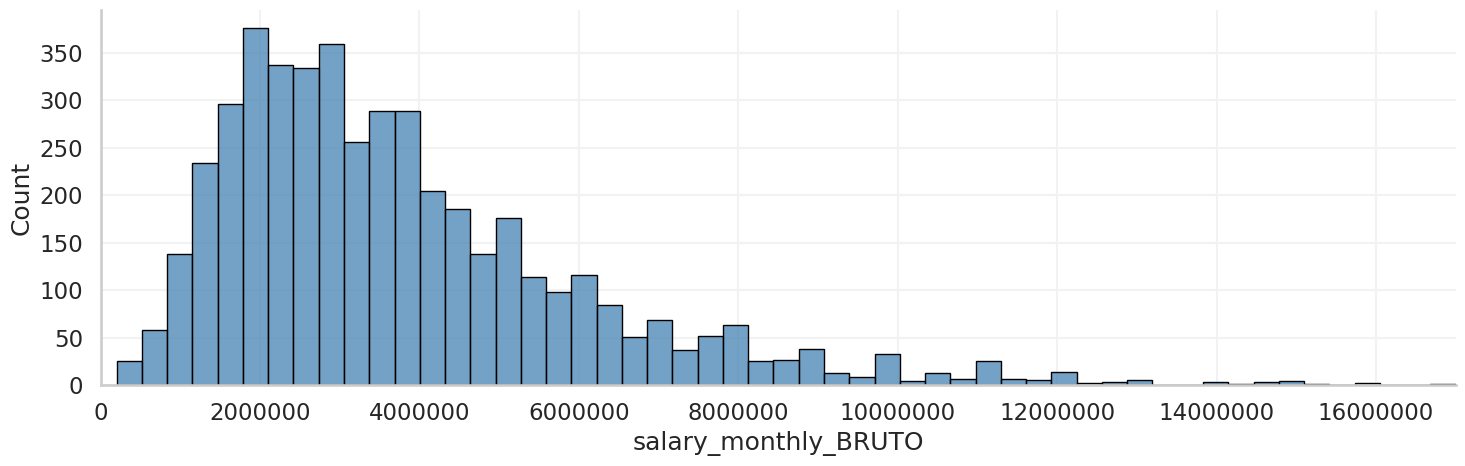

In [ ]:
# Distribución de salario BRUTO
max_bruto = max(df_bounded["salary_monthly_BRUTO"])

sns.displot(df_bounded["salary_monthly_BRUTO"],
            aspect=3,color = "steelblue",
            edgecolor = "black",
            linewidth = 1)
plt.ticklabel_format(style='plain', axis='x')
plt.xlim((0,max_bruto))

(0.0, 11820000.0)

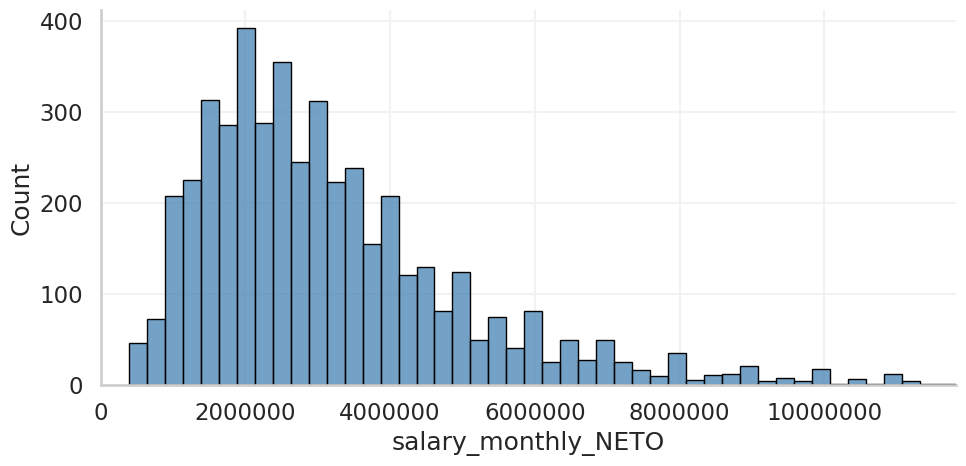

In [ ]:
# Distribución de salario NETO
max_neto = max(df_bounded["salary_monthly_NETO"])

sns.displot(df_bounded["salary_monthly_NETO"],
            aspect=2,color = "steelblue",
            edgecolor = "black",
            linewidth = 1)
plt.ticklabel_format(style='plain', axis='x')
plt.xlim((0,max_neto))

In [ ]:
# Verificación BRUTO > NETO
consistency = df_bounded.salary_monthly_BRUTO > df_bounded.salary_monthly_NETO

# Contar la cantidad de veces que se cumple la condición
count_true = consistency.sum()
count_false = (~consistency).sum()

print(f"Filas donde BRUTO > NETO: {count_true}")
print(f"Filas donde BRUTO <= NETO: {count_false}")

Filas donde BRUTO > NETO: 3977
Filas donde BRUTO <= NETO: 642


In [ ]:
# Agregar flagger (booleano)
df_bounded['bruto_mayor_que_neto'] = consistency

# Eliminar filas con ratio > 1.5: Errores evidentes
df_bounded = df_bounded[
    df_bounded['salary_monthly_NETO'] / df_bounded['salary_monthly_BRUTO'] < 1.5]

df_bounded[["salary_monthly_BRUTO", "salary_monthly_NETO"]].describe()

,salary_monthly_BRUTO,salary_monthly_NETO
count,4.581000e+03,4.581000e+03
mean,3.801095e+06,3.179284e+06
std,2.288024e+06,1.867186e+06
min,4.000000e+05,3.900000e+05
25%,2.198917e+06,1.880000e+06
50%,3.248203e+06,2.736180e+06
75%,4.883219e+06,4.000000e+06
max,1.700000e+07,1.182000e+07


In [ ]:
# Se considera la subpoblacion con dedicacion Full-Time
df_bounded.groupby("work_dedication")["salary_monthly_NETO"].describe()

# Eliminar filas con work_dedication Part time en un nuevo df restringido
df_restricted = df_bounded.drop(df_bounded[df_bounded["work_dedication"] == "Part-Time"].index)
df_restricted["salary_monthly_NETO"].describe()

,salary_monthly_NETO
count,4.391000e+03
mean,3.231857e+06
std,1.863610e+06
min,3.900000e+05
25%,1.921388e+06
50%,2.800000e+06
75%,4.000000e+06
max,1.182000e+07


In [ ]:
df_restricted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4391 entries, 0 to 4938
Data columns (total 61 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   work_province                                         4391 non-null   object 
 1   work_dedication                                       4391 non-null   object 
 2   work_contract_type                                    4391 non-null   object 
 3   salary_monthly_BRUTO                                  4391 non-null   float64
 4   salary_monthly_NETO                                   4391 non-null   float64
 5   salary_in_usd                                         1327 non-null   object 
 6   salary_last_dollar_value                              880 non-null    object 
 7   salary_has_bonus                                      4391 non-null   object 
 8   salary_bonus_tied_to                                  4391 non-

#### Resumen de lo obtenido hasta aquí:

En este punto se tiene un data set libre de duplicados, nulos y outliers en las columnas de interés, con un rango salarial neto entre los cuantiles 1% y 99%, restringido a dedicación Full-Time. Se identificaron los casos en que NETO >= BRUTO. Además, se admite la posibilidad de segmentar el estudio a seniorities específicas (Junior, Semi-senior y Senior). Se optó por no segmentar el estudio en función del puesto, a fin de incluir una diversidad de lenguajes mayor en el estudio.  

### Conteo de frecuencias de lenguajes

In [ ]:
df_restricted.tools_programming_languages[:3]

,tools_programming_languages
0,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL"
1,".NET, C#, HTML, Javascript, SQL"
2,"Go, SQL"


In [ ]:
# Separación de lenguajes como variables independientes

# Función para convertir los lenguajes separados por coma en una lista
# Remove 'ninguno de los anteriores' option, spaces and training commas.
def split_languages(languages_str):
  if not isinstance(languages_str, str):
    return []
  languages_str = languages_str.lower().replace('ninguno de los anteriores', '')
  return [lang.strip().replace(',', '') for lang in languages_str.split()]

# Se aplica la función a la  tabla filtrada
# Create a new column with the list of languages
df_restricted.loc[:, 'cured_languages'] = df_restricted\
    .tools_programming_languages\
    .apply(split_languages)

if 'cured_languages' not in relevant_columns:
    relevant_columns.append('cured_languages')

# Separación de los lenguajes en filas individuales
df_lang = df_restricted.explode('cured_languages')

# Limpieza de filas vacías
df_lang = df_lang.dropna(subset=['cured_languages'])
df_lang = df_lang[df_lang['cured_languages'] != '']

df_lang[:5]

,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,salary_inflation_adjustment,...,profile_age,profile_gender,profile_previous_survey,company_best_companies,sueldo_dolarizado,work_seniority,_sal,bruto_mayor_que_neto,cured_programming_languages,cured_languages
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0,True,"[.net, c#, css, go, html, java, javascript, sql]",.net
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0,True,"[.net, c#, css, go, html, java, javascript, sql]",c#
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0,True,"[.net, c#, css, go, html, java, javascript, sql]",css
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0,True,"[.net, c#, css, go, html, java, javascript, sql]",go
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0,True,"[.net, c#, css, go, html, java, javascript, sql]",html


In [ ]:
# Conteo del número de programadores que utilizan X lenguaje
language_count = df_lang['cured_languages'].value_counts()\
    .reset_index()\
    .rename(columns={'index': 'language', 'programming_language': 'frequency'})
language_count[:16]

,cured_languages,count
0,sql,1982
1,javascript,1652
2,python,1562
3,html,1220
4,typescript,1012
5,bash/shell,784
6,css,774
7,java,714
8,php,491
9,.net,490


In [ ]:
# Considero para el estudio los lenguajes con una cantidad superior a 100
# usuarios, para robustecer la estadística.
interesting_languages = df_lang['cured_languages']\
                                 .value_counts().head(15).index

# Dafa frame final de trabajo
df_final = df_lang[df_lang['cured_languages']\
                   .isin(interesting_languages)].copy()

# Visualización
visual = df_lang['cured_languages'].value_counts().head(15).reset_index()
visual.columns = ['lenguaje', 'frecuencia']

print("Los 15 lenguajes más populares son:")
print(visual)


Los 15 lenguajes más populares son:
      lenguaje  frecuencia
0          sql        1982
1   javascript        1652
2       python        1562
3         html        1220
4   typescript        1012
5   bash/shell         784
6          css         774
7         java         714
8          php         491
9         .net         490
10          c#         396
11          go         247
12      kotlin         122
13         vba         117
14         c++         112


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11675 entries, 0 to 4938
Data columns (total 63 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   work_province                                         11675 non-null  object 
 1   work_dedication                                       11675 non-null  object 
 2   work_contract_type                                    11675 non-null  object 
 3   salary_monthly_BRUTO                                  11675 non-null  float64
 4   salary_monthly_NETO                                   11675 non-null  float64
 5   salary_in_usd                                         3718 non-null   object 
 6   salary_last_dollar_value                              2373 non-null   object 
 7   salary_has_bonus                                      11675 non-null  object 
 8   salary_bonus_tied_to                                  11675 no

In [ ]:
# Ordeno decrecientemente los lenguajes mejores pagos dentro de los más
# populares en términos de la mediana.

# Uso de la mediana como estadística comparativa para mayor robustez.
df_final.groupby("cured_languages")["salary_monthly_NETO"]\
.describe().sort_values(by="50%", ascending=False)

,count,mean,std,min,25%,50%,75%,max
cured_languages,,,,,,,,
go,247.0,4.551523e+06,2.246635e+06,600000.00,2.999000e+06,3958855.0,5850000.00,11330000.0
kotlin,122.0,4.123837e+06,1.934960e+06,400000.00,2.613970e+06,3855284.0,5137500.00,10000000.0
c++,112.0,3.701843e+06,2.145915e+06,400000.00,1.886835e+06,3453559.5,5000000.00,11000000.0
java,714.0,3.582146e+06,1.838214e+06,400000.00,2.245214e+06,3200000.0,4552500.00,11300000.0
typescript,1012.0,3.550030e+06,2.093740e+06,423000.00,2.054328e+06,3011066.5,4450750.00,11330000.0
bash/shell,784.0,3.528058e+06,1.921064e+06,400000.00,2.100000e+06,3010231.0,4500000.00,11330000.0
python,1562.0,3.471942e+06,1.982639e+06,400000.00,2.084054e+06,3000000.0,4300000.00,11268613.0
javascript,1652.0,3.330502e+06,1.954187e+06,400000.00,1.923375e+06,2900000.0,4200000.00,11300000.0
c#,396.0,3.255196e+06,1.791460e+06,400000.00,2.000000e+06,2800000.0,4000000.00,10440000.0


### Visualizaciones

3. Se eligió comparar distribuciones mediante visualizaciones, utilizando Boxplots y Barplots ordenados por mediana. Esto permite identificar rápidamente no solo los niveles salariales centrales de cada teconología, sino la dispersión y presencia de valores atípicos, ofreciendo una visión más robusta.

Aún así, se observa que la distirbución de salarios presenta un marcado sesgo a la derecha, donde unos pocos salarios muy elevados pueden desplazar la media hacia valores no representativos.

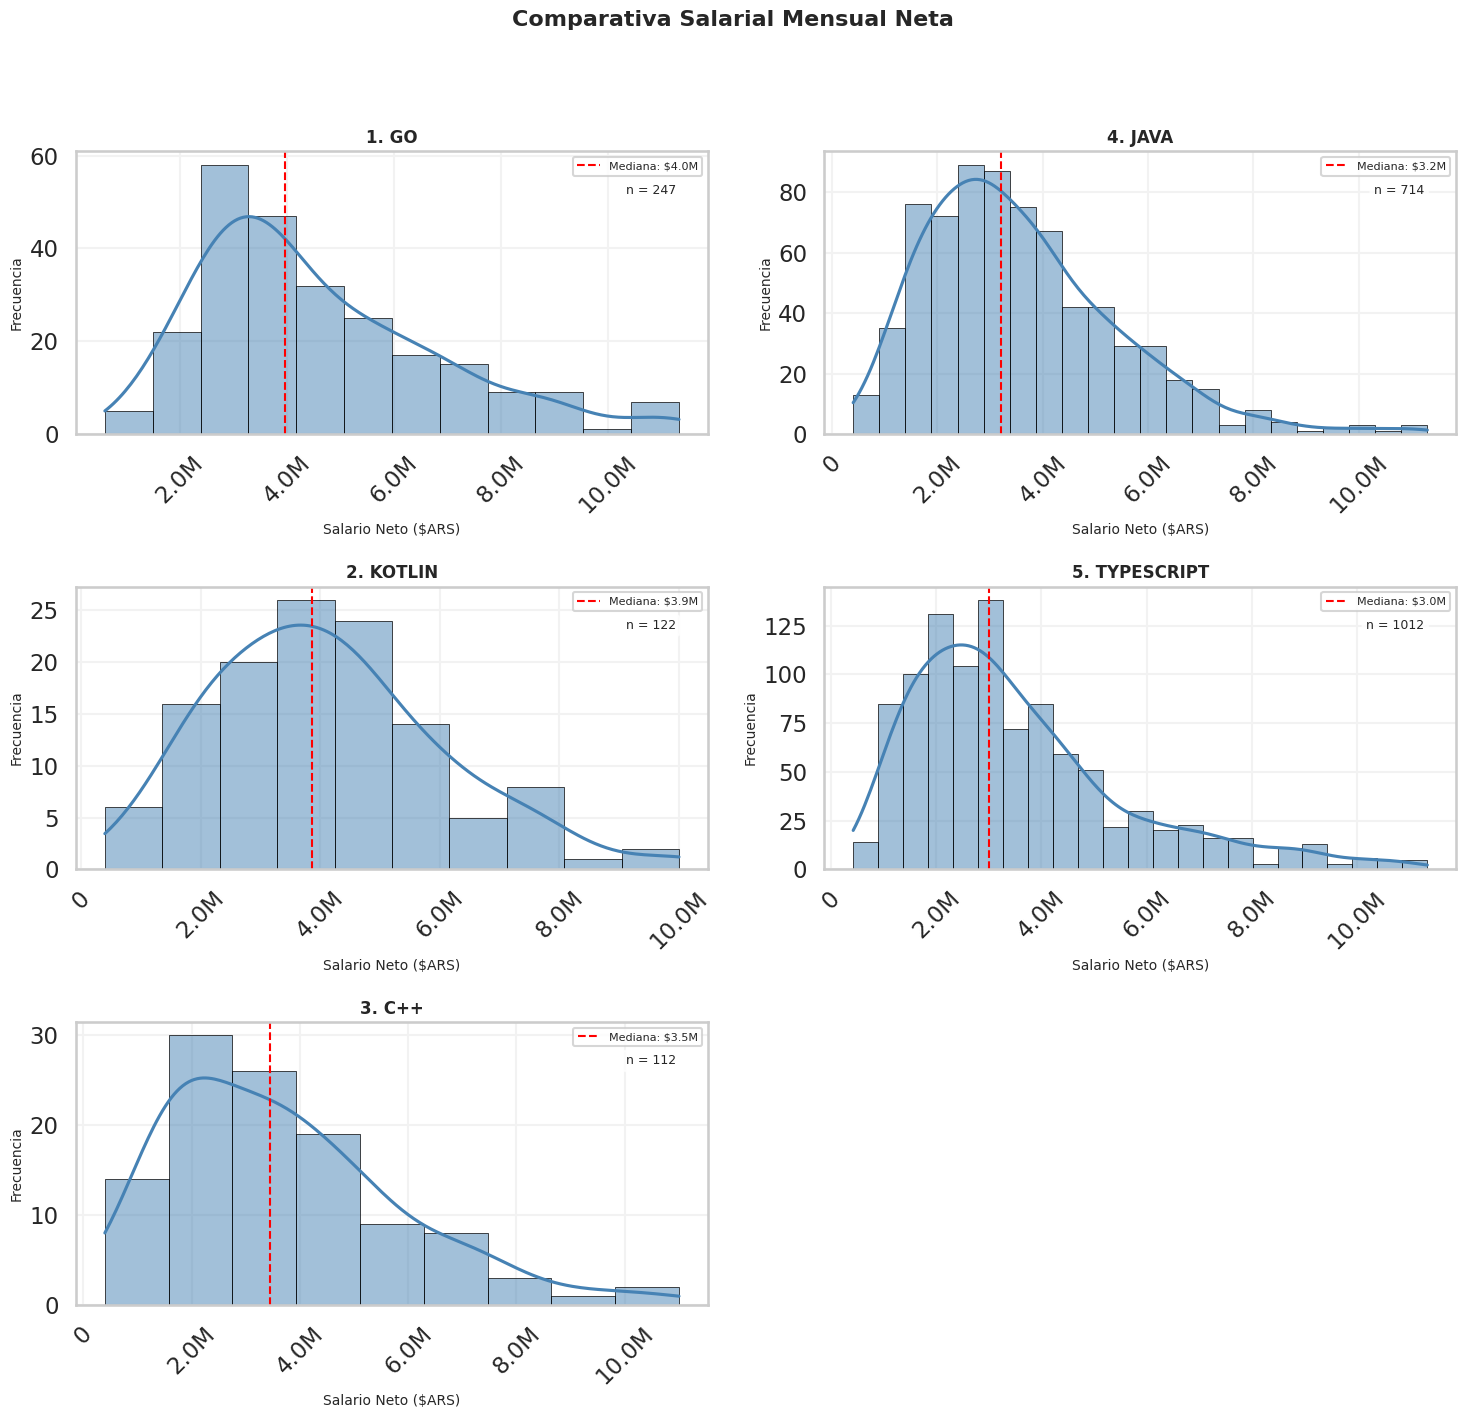

In [ ]:
# Visualizacion comparativa de la distribucion salarial neta entre los 5
# lenguajes asociados a los mayores sueldos (por mediana).

# Identificacion del Top 5
top_5_languages = (
    df_final.groupby('cured_languages')['salary_monthly_NETO']
    .median()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

# Configuracion de la matriz
rows, cols = 3, 2
fig, axes = plt.subplots(rows, cols, figsize=(15, 15))

# Llenado de la matriz por columnas
# .T transpone la matriz de ejes y .flatten() la aplana.
# Esto hace que el orden de los ejes en la lista sea:
# (0,0), (1,0), (2,0) -> Primera columna
# (0,1), (1,1), (2,1) -> Segunda columna
axes_flat = axes.T.flatten()

sns.set_style("whitegrid", {'axes.grid': True, 'grid.color': '.95'})

def salary_formatter_m(x, pos):
    millions = x * 1e-6
    return f'{millions:.1f}M' if x != 0 else '0'

# Iteraciones sobre la lista reordenada
for i, lang in enumerate(top_5_languages):
    ax = axes_flat[i]
    data_lang = df_final[df_final['cured_languages'] == lang]['salary_monthly_NETO']

    sns.histplot(data_lang, kde=True, color='steelblue', edgecolor='black', linewidth=0.5, ax=ax)

    # Mediana
    median_val = data_lang.median()
    ax.axvline(median_val, color='red', linestyle='--', linewidth=1.5,
               label=f'Mediana: ${median_val*1e-6:.1f}M')

    # Formateo
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(salary_formatter_m))
    ax.tick_params(axis='x', rotation=45)

    ax.set_title(f'{i+1}. {lang.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Salario Neto ($ARS)', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)

    ax.text(0.95, 0.85, f'n = {len(data_lang)}', transform=ax.transAxes,
            fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
            horizontalalignment='right')
    ax.legend(fontsize=8)

# Eliminacion de ejes sobrantes
# Como tenemos 5 lenguajes y 6 espacios, el último de la segunda columna (axes_flat[5]) estará vacío
if len(top_5_languages) < len(axes_flat):
    for j in range(len(top_5_languages), len(axes_flat)):
        fig.delaxes(axes_flat[j])

plt.suptitle('Comparativa Salarial Mensual Neta', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

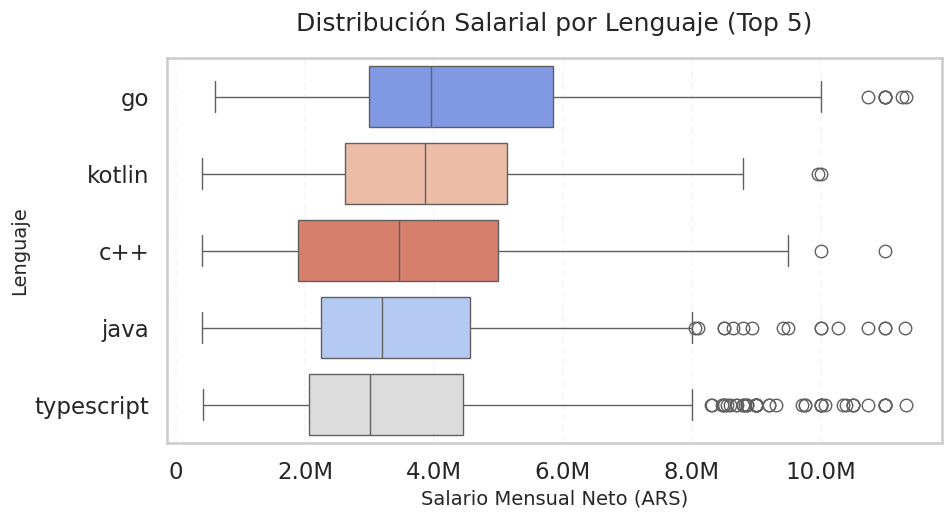

In [ ]:
# Visualizacion comparativa usando boxplot.

# Filtrado del dataset
df_boxplot = df_final[df_final['cured_languages'].isin(top_5_languages)]

# Creación de figura
fig, ax = plt.subplots(figsize=(10, 5))

# Gráfico de Cajas
sns.boxplot(data=df_boxplot,
            x='salary_monthly_NETO',
            y='cured_languages',
            order=top_5_languages,
            hue='cured_languages', # <--- Soluciona el FutureWarning
            legend=False,          # <--- Quita la leyenda redundante
            palette='coolwarm',
            ax=ax)

# Formateo
ax.ticklabel_format(style='plain', axis='x')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(salary_formatter_m))

# Estética
ax.set_title('Distribución Salarial por Lenguaje (Top 5)', fontsize=18, pad=20)
ax.set_xlabel('Salario Mensual Neto (ARS)', fontsize=14)
ax.set_ylabel('Lenguaje', fontsize=14)
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.show()

In [ ]:
print("Métricas Estadísticas por Lenguaje (Ordenadas por Mediana):")

summary = df_final.groupby('cured_languages')['salary_monthly_NETO']\
    .agg(['median', 'mean', 'count'])\
    .sort_values(by='median', ascending=False)

summary.columns = ['Mediana', 'Media (Promedio)', 'N (Muestra)']

display(summary)

Métricas Estadísticas por Lenguaje (Ordenadas por Mediana):


,Mediana,Media (Promedio),N (Muestra)
cured_languages,,,
go,3958855.0,4.551523e+06,247
kotlin,3855284.0,4.123837e+06,122
c++,3453559.5,3.701843e+06,112
java,3200000.0,3.582146e+06,714
typescript,3011066.5,3.550030e+06,1012
bash/shell,3010231.0,3.528058e+06,784
python,3000000.0,3.471942e+06,1562
javascript,2900000.0,3.330502e+06,1652
c#,2800000.0,3.255196e+06,396


### Análisis final

La pregunta inicial era: **¿Cuáles son los lenguajes asociados a los mejores salarios?**
Con el procesamiento y análisis previo resulta conveniente reformularla: **¿Cuáles son los lenguajes asociados a los mejores salarios netos entre programadores Full-Time?**

Las visualizaciones implementadas permiten identificar rápidamente las brechas salariales entre lenguajes, mientras que la tabla de estadística descriptiva aporta los valores numéricos para un análisis más preciso.

En ambos gráficos se tiene como indicador principal la mediana para garantizar mayor robustez estadística. Se utiliza como mejor estimador del *sueldo típico*.

La caja del boxplot da una medida de la dispersión de los datos dentro del rango intercuartílico comparable más clara que la distribución de barras del barplot.

En ambos resulta evidente el sesgo positivo de la distribución salarial. Esto fundamenta la elección de la mediana frente a la media, la cual se ve arrastrada por los salarios altos, sobreestimando el ingreso real.

#### Conclusiones

Se observa que GO es el lenguaje que lidera el ranking salarial, seguido por Kotlin y C++.

Cabe aclarar que el volumen de datos disponibles sobre estos lenguajes es menor que los demás tecnologías estudiadas.

Se observa una mayor dispersión salarial asociada a C++, mientras que Java posee el rango más concentrado.  





